In [447]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [628]:
df_matches = pd.read_csv("/Users/samueleferrucci/Documents/Coding/Projects/Tennis ML/data/clean/merged_matches.csv")

In [629]:
cols = ["p1_first_serve", "p1_1st_serve_points_won", "p1_2nd_serve_points_won",                             # Defining columns for stats
        "p1_1st_serve_return_points_won", "p1_service_points_won", "p1_2nd_serve_return_points_won", "p1_return_points_won", "p1_total_points_won",
        "p2_first_serve", "p2_1st_serve_points_won", "p2_2nd_serve_points_won",
        "p2_1st_serve_return_points_won", "p2_service_points_won", "p2_2nd_serve_return_points_won", "p2_return_points_won", "p2_total_points_won"]
cols2 = ["p1_break_points_saved", "p1_break_points_converted", "p1_net_points_won",
        "p2_break_points_saved", "p2_break_points_converted", "p2_net_points_won"]
new_cols = ["p2_break_point_opportunities", "p1_break_point_opportunities", "p1_net_points_played",
        "p2_net_points_played"]
tot_cols = cols+cols2+new_cols + ["p2_serve_rating", "p2_aces",
                                  "p2_double_faults", "p2_service_games_played",
                                  "p2_return_rating", "p2_return_games_played",
                                  "p2_winners", "p2_unforced_errors", "p2_max_speed",
                                  "p2_1st_serve_average_speed", "p2_2nd_serve_average_speed",
                                  "p1_break_point_opportunities", "p1_net_points_played",
                                  'p1_serve_rating', 'p1_aces', 'p1_double_faults',
       'p1_first_serve', 'p1_1st_serve_points_won', 'p1_2nd_serve_points_won',
       'p1_break_points_saved', 'p1_service_games_played', 'p1_return_rating',
       'p1_1st_serve_return_points_won', 'p1_2nd_serve_return_points_won',
       'p1_break_points_converted', 'p1_return_games_played',
       'p1_net_points_won', 'p1_winners', 'p1_unforced_errors',
       'p1_service_points_won', 'p1_return_points_won', 'p1_total_points_won',
       'p1_max_speed', 'p1_1st_serve_average_speed',
       'p1_2nd_serve_average_speed', 'p1_break_point_opportunities',
       'p1_net_points_played']
tot_cols = list(set(tot_cols))

In [630]:
for col in tot_cols:
    if 'p2' in col:
        print(col)

p2_service_points_won
p2_first_serve
p2_break_points_converted
p2_total_points_won
p2_break_points_saved
p2_2nd_serve_return_points_won
p2_unforced_errors
p2_2nd_serve_points_won
p2_1st_serve_return_points_won
p2_net_points_won
p2_return_rating
p2_net_points_played
p2_winners
p2_max_speed
p2_aces
p2_service_games_played
p2_return_points_won
p2_1st_serve_points_won
p2_double_faults
p2_2nd_serve_average_speed
p2_serve_rating
p2_return_games_played
p2_break_point_opportunities
p2_1st_serve_average_speed


In [631]:
p1_df = df_matches.copy()

for col in tot_cols:
    if 'p2' in col:
        p1_df.drop(columns=col, inplace=True)

p1_df

,match_date,player_1,player_2,duration,match_round,player_1_scores,player_2_scores,winner,result,match_id,...,p1_winners,p1_unforced_errors,p1_service_points_won,p1_return_points_won,p1_total_points_won,p1_max_speed,p1_1st_serve_average_speed,p1_2nd_serve_average_speed,p1_break_point_opportunities,p1_net_points_played
0,2025-05-24,A. Rublev,F. Cobolli,0 days 01:28:37,Final,2 4,6 6,F. Cobolli,Completed,ms001,...,10.0,23.0,0.50,0.39,0.43,NaN,NaN,NaN,7.0,7.0
1,2025-05-23,F. Auger-Aliassime,A. Rublev,0 days 01:25:13,Semi-Finals,1 4,6 6,A. Rublev,Completed,ms002,...,15.0,24.0,0.57,0.27,0.42,NaN,NaN,NaN,1.0,2.0
2,2025-05-23,T. Etcheverry,F. Cobolli,0 days 02:47:54,Semi-Finals,6 5 4,2 7 6,F. Cobolli,Completed,ms003,...,20.0,34.0,0.62,0.40,0.51,NaN,NaN,NaN,7.0,16.0
3,2025-05-22,A. Rublev,L. Darderi,0 days 01:53:35,Quarter-Finals,6 3 6,1 6 3,A. Rublev,Completed,ms005,...,32.0,23.0,0.69,0.39,0.54,NaN,NaN,NaN,7.0,12.0
4,2025-05-22,A. Muller,F. Auger-Aliassime,0 days 02:58:31,Quarter-Finals,6(4) 7 3,7 6(6) 6,F. Auger-Aliassime,Completed,ms004,...,18.0,35.0,0.62,0.36,0.49,NaN,NaN,NaN,6.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,2025-07-19 00:00:00,T. Monteiro,N. Oberleitner,0 days 02:41:05,1st Round Qualifying,6 4 7,4 6 6(4),T. Monteiro,Completed,qs014,...,31.0,37.0,0.69,0.37,0.52,NaN,NaN,NaN,8.0,8.0
4236,2025-07-19 00:00:00,R. Albot,J. Kym,0 days 02:08:57,1st Round Qualifying,2 7 6,6 6(3) 3,R. Albot,Completed,qs013,...,20.0,44.0,0.58,0.35,0.48,NaN,NaN,NaN,13.0,5.0
4237,2025-07-19 00:00:00,F. Bagnis,H. Rocha,0 days 01:24:25,1st Round Qualifying,6 6,4 3,F. Bagnis,Completed,qs015,...,16.0,21.0,0.68,0.47,0.57,NaN,NaN,NaN,4.0,13.0
4238,2025-07-19 00:00:00,S. Kopp,J. Rodionov,0 days 01:20:52,1st Round Qualifying,3 6(3),6 7,J. Rodionov,Completed,qs009,...,15.0,24.0,0.67,0.34,0.48,NaN,NaN,NaN,5.0,3.0


In [632]:
p2_df = df_matches.copy()

for col in tot_cols:
    if 'p1' in col:
        p2_df.drop(columns=col, inplace=True)

p2_df

,match_date,player_1,player_2,duration,match_round,player_1_scores,player_2_scores,winner,result,match_id,...,p2_winners,p2_unforced_errors,p2_service_points_won,p2_return_points_won,p2_total_points_won,p2_max_speed,p2_1st_serve_average_speed,p2_2nd_serve_average_speed,p2_break_point_opportunities,p2_net_points_played
0,2025-05-24,A. Rublev,F. Cobolli,0 days 01:28:37,Final,2 4,6 6,F. Cobolli,Completed,ms001,...,25.0,24.0,0.61,0.50,0.57,NaN,NaN,NaN,4.0,5.0
1,2025-05-23,F. Auger-Aliassime,A. Rublev,0 days 01:25:13,Semi-Finals,1 4,6 6,A. Rublev,Completed,ms002,...,18.0,12.0,0.73,0.43,0.58,NaN,NaN,NaN,7.0,8.0
2,2025-05-23,T. Etcheverry,F. Cobolli,0 days 02:47:54,Semi-Finals,6 5 4,2 7 6,F. Cobolli,Completed,ms003,...,40.0,53.0,0.60,0.38,0.49,NaN,NaN,NaN,10.0,10.0
3,2025-05-22,A. Rublev,L. Darderi,0 days 01:53:35,Quarter-Finals,6 3 6,1 6 3,A. Rublev,Completed,ms005,...,22.0,22.0,0.61,0.31,0.46,NaN,NaN,NaN,6.0,4.0
4,2025-05-22,A. Muller,F. Auger-Aliassime,0 days 02:58:31,Quarter-Finals,6(4) 7 3,7 6(6) 6,F. Auger-Aliassime,Completed,ms004,...,40.0,61.0,0.64,0.38,0.51,NaN,NaN,NaN,12.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,2025-07-19 00:00:00,T. Monteiro,N. Oberleitner,0 days 02:41:05,1st Round Qualifying,6 4 7,4 6 6(4),T. Monteiro,Completed,qs014,...,39.0,49.0,0.63,0.31,0.48,NaN,NaN,NaN,9.0,27.0
4236,2025-07-19 00:00:00,R. Albot,J. Kym,0 days 02:08:57,1st Round Qualifying,2 7 6,6 6(3) 3,R. Albot,Completed,qs013,...,27.0,45.0,0.65,0.42,0.52,NaN,NaN,NaN,10.0,6.0
4237,2025-07-19 00:00:00,F. Bagnis,H. Rocha,0 days 01:24:25,1st Round Qualifying,6 6,4 3,F. Bagnis,Completed,qs015,...,16.0,28.0,0.53,0.32,0.43,NaN,NaN,NaN,3.0,2.0
4238,2025-07-19 00:00:00,S. Kopp,J. Rodionov,0 days 01:20:52,1st Round Qualifying,3 6(3),6 7,J. Rodionov,Completed,qs009,...,26.0,25.0,0.66,0.33,0.52,NaN,NaN,NaN,3.0,9.0


In [633]:
p1_df.rename(columns={"player_1": "player", "player_2": "opponent", "player_1_scores": "player_scores",
                      "player_2_scores": "opponent_scores", "p1_id": "id", "p2_id": "opponent_id", "p1_set1": "set1",
                      'p1_set2': 'set2',
                    'p1_set3': 'set3',
                    'p1_set4': 'set4',
                    'p1_set5': 'set5',
                    'p2_set1': 'opponent_set1',
                    'p2_set2': 'opponent_set2',
                    'p2_set3': 'opponent_set3',
                    'p2_set4': 'opponent_set4',
                    'p2_set5': 'opponent_set5',
                    'p1_serve_rating': 'serve_rating',
                    'p1_aces': 'aces',
                    'p1_double_faults': 'double_faults',
                    'p1_first_serve': 'first_serve',
                    'p1_1st_serve_points_won': '1st_serve_points_won',
                    'p1_2nd_serve_points_won': '2nd_serve_points_won',
                    'p1_break_points_saved': 'break_points_saved',
                    'p1_service_games_played': 'service_games_played',
                    'p1_return_rating': 'return_rating',
                    'p1_1st_serve_return_points_won': '1st_serve_return_points_won',
                    'p1_2nd_serve_return_points_won': '2nd_serve_return_points_won',
                    'p1_break_points_converted': 'break_points_converted',
                    'p1_return_games_played': 'return_games_played',
                    'p1_net_points_won': 'net_points_won',
                    'p1_winners': 'winners',
                    'p1_unforced_errors': 'unforced_errors',
                    'p1_service_points_won': 'service_points_won',
                    'p1_return_points_won': 'return_points_won',
                    'p1_total_points_won': 'total_points_won',
                    'p1_max_speed': 'max_speed',
                    'p1_1st_serve_average_speed': '1st_serve_average_speed',
                    'p1_2nd_serve_average_speed': '2nd_serve_average_speed',
                    'p1_break_point_opportunities': 'break_point_opportunities',
                    'p1_net_points_played': 'net_points_played'}, inplace=True)

In [634]:
p2_df.rename(columns={"player_1": "opponent", "player_2": "player", "player_1_scores": "opponent_scores",
                      "player_2_scores": "player_scores", "p2_id": "id", "p1_id": "opponent_id",
                      'p1_set1': 'opponent_set1',
                        'p1_set2': 'opponent_set2',
                        'p1_set3': 'opponent_set3',
                        'p1_set4': 'opponent_set4',
                        'p1_set5': 'opponent_set5',
                        'p2_set1': 'set1',
                        'p2_set2': 'set2',
                        'p2_set3': 'set3',
                        'p2_set4': 'set4',
                        'p2_set5': 'set5',
                        'p2_serve_rating': 'serve_rating',
                        'p2_aces': 'aces',
                        'p2_double_faults': 'double_faults',
                        'p2_first_serve': 'first_serve',
                        'p2_1st_serve_points_won': '1st_serve_points_won',
                        'p2_2nd_serve_points_won': '2nd_serve_points_won',
                        'p2_break_points_saved': 'break_points_saved',
                        'p2_service_games_played': 'service_games_played',
                        'p2_return_rating': 'return_rating',
                        'p2_1st_serve_return_points_won': '1st_serve_return_points_won',
                        'p2_2nd_serve_return_points_won': '2nd_serve_return_points_won',
                        'p2_break_points_converted': 'break_points_converted',
                        'p2_return_games_played': 'return_games_played',
                        'p2_net_points_won': 'net_points_won',
                        'p2_winners': 'winners',
                        'p2_unforced_errors': 'unforced_errors',
                        'p2_service_points_won': 'service_points_won',
                        'p2_return_points_won': 'return_points_won',
                        'p2_total_points_won': 'total_points_won',
                        'p2_max_speed': 'max_speed',
                        'p2_1st_serve_average_speed': '1st_serve_average_speed',
                        'p2_2nd_serve_average_speed': '2nd_serve_average_speed',
                        'p2_break_point_opportunities': 'break_point_opportunities',
                        'p2_net_points_played': 'net_points_played'}, inplace=True)

In [635]:
p1_df.columns == p2_df.columns

array([ True, False, False,  True,  True, False, False,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
       False, False, False, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

In [636]:
p1_df

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,match_id,...,winners,unforced_errors,service_points_won,return_points_won,total_points_won,max_speed,1st_serve_average_speed,2nd_serve_average_speed,break_point_opportunities,net_points_played
0,2025-05-24,A. Rublev,F. Cobolli,0 days 01:28:37,Final,2 4,6 6,F. Cobolli,Completed,ms001,...,10.0,23.0,0.50,0.39,0.43,NaN,NaN,NaN,7.0,7.0
1,2025-05-23,F. Auger-Aliassime,A. Rublev,0 days 01:25:13,Semi-Finals,1 4,6 6,A. Rublev,Completed,ms002,...,15.0,24.0,0.57,0.27,0.42,NaN,NaN,NaN,1.0,2.0
2,2025-05-23,T. Etcheverry,F. Cobolli,0 days 02:47:54,Semi-Finals,6 5 4,2 7 6,F. Cobolli,Completed,ms003,...,20.0,34.0,0.62,0.40,0.51,NaN,NaN,NaN,7.0,16.0
3,2025-05-22,A. Rublev,L. Darderi,0 days 01:53:35,Quarter-Finals,6 3 6,1 6 3,A. Rublev,Completed,ms005,...,32.0,23.0,0.69,0.39,0.54,NaN,NaN,NaN,7.0,12.0
4,2025-05-22,A. Muller,F. Auger-Aliassime,0 days 02:58:31,Quarter-Finals,6(4) 7 3,7 6(6) 6,F. Auger-Aliassime,Completed,ms004,...,18.0,35.0,0.62,0.36,0.49,NaN,NaN,NaN,6.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,2025-07-19 00:00:00,T. Monteiro,N. Oberleitner,0 days 02:41:05,1st Round Qualifying,6 4 7,4 6 6(4),T. Monteiro,Completed,qs014,...,31.0,37.0,0.69,0.37,0.52,NaN,NaN,NaN,8.0,8.0
4236,2025-07-19 00:00:00,R. Albot,J. Kym,0 days 02:08:57,1st Round Qualifying,2 7 6,6 6(3) 3,R. Albot,Completed,qs013,...,20.0,44.0,0.58,0.35,0.48,NaN,NaN,NaN,13.0,5.0
4237,2025-07-19 00:00:00,F. Bagnis,H. Rocha,0 days 01:24:25,1st Round Qualifying,6 6,4 3,F. Bagnis,Completed,qs015,...,16.0,21.0,0.68,0.47,0.57,NaN,NaN,NaN,4.0,13.0
4238,2025-07-19 00:00:00,S. Kopp,J. Rodionov,0 days 01:20:52,1st Round Qualifying,3 6(3),6 7,J. Rodionov,Completed,qs009,...,15.0,24.0,0.67,0.34,0.48,NaN,NaN,NaN,5.0,3.0


In [637]:
p2_df

,match_date,opponent,player,duration,match_round,opponent_scores,player_scores,winner,result,match_id,...,winners,unforced_errors,service_points_won,return_points_won,total_points_won,max_speed,1st_serve_average_speed,2nd_serve_average_speed,break_point_opportunities,net_points_played
0,2025-05-24,A. Rublev,F. Cobolli,0 days 01:28:37,Final,2 4,6 6,F. Cobolli,Completed,ms001,...,25.0,24.0,0.61,0.50,0.57,NaN,NaN,NaN,4.0,5.0
1,2025-05-23,F. Auger-Aliassime,A. Rublev,0 days 01:25:13,Semi-Finals,1 4,6 6,A. Rublev,Completed,ms002,...,18.0,12.0,0.73,0.43,0.58,NaN,NaN,NaN,7.0,8.0
2,2025-05-23,T. Etcheverry,F. Cobolli,0 days 02:47:54,Semi-Finals,6 5 4,2 7 6,F. Cobolli,Completed,ms003,...,40.0,53.0,0.60,0.38,0.49,NaN,NaN,NaN,10.0,10.0
3,2025-05-22,A. Rublev,L. Darderi,0 days 01:53:35,Quarter-Finals,6 3 6,1 6 3,A. Rublev,Completed,ms005,...,22.0,22.0,0.61,0.31,0.46,NaN,NaN,NaN,6.0,4.0
4,2025-05-22,A. Muller,F. Auger-Aliassime,0 days 02:58:31,Quarter-Finals,6(4) 7 3,7 6(6) 6,F. Auger-Aliassime,Completed,ms004,...,40.0,61.0,0.64,0.38,0.51,NaN,NaN,NaN,12.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,2025-07-19 00:00:00,T. Monteiro,N. Oberleitner,0 days 02:41:05,1st Round Qualifying,6 4 7,4 6 6(4),T. Monteiro,Completed,qs014,...,39.0,49.0,0.63,0.31,0.48,NaN,NaN,NaN,9.0,27.0
4236,2025-07-19 00:00:00,R. Albot,J. Kym,0 days 02:08:57,1st Round Qualifying,2 7 6,6 6(3) 3,R. Albot,Completed,qs013,...,27.0,45.0,0.65,0.42,0.52,NaN,NaN,NaN,10.0,6.0
4237,2025-07-19 00:00:00,F. Bagnis,H. Rocha,0 days 01:24:25,1st Round Qualifying,6 6,4 3,F. Bagnis,Completed,qs015,...,16.0,28.0,0.53,0.32,0.43,NaN,NaN,NaN,3.0,2.0
4238,2025-07-19 00:00:00,S. Kopp,J. Rodionov,0 days 01:20:52,1st Round Qualifying,3 6(3),6 7,J. Rodionov,Completed,qs009,...,26.0,25.0,0.66,0.33,0.52,NaN,NaN,NaN,3.0,9.0


In [638]:
player_stats_df = pd.concat([p1_df, p2_df], ignore_index=True)

In [639]:
player_stats_df.sort_values(by="match_date", ascending=False)

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,match_id,...,winners,unforced_errors,service_points_won,return_points_won,total_points_won,max_speed,1st_serve_average_speed,2nd_serve_average_speed,break_point_opportunities,net_points_played
4136,2025-07-27 00:00:00,A. Davidovich Fokina,A. De Minaur,0 days 03:03:35,Final,7 1 6(3),5 6 7,A. De Minaur,Completed,ms001,...,28.0,57.0,0.58,0.37,0.48,NaN,NaN,NaN,8.0,7.0
8376,2025-07-27 00:00:00,A. De Minaur,A. Davidovich Fokina,0 days 03:03:35,Final,5 6 7,7 1 6(3),A. De Minaur,Completed,ms001,...,23.0,45.0,0.63,0.42,0.52,NaN,NaN,NaN,9.0,12.0
8441,2025-07-26 00:00:00,A. Cazaux,A. Bublik,0 days 01:24:45,Final,4 3,6 6,A. Bublik,Completed,ms001,...,18.0,17.0,0.59,0.31,0.45,NaN,NaN,NaN,5.0,12.0
8339,2025-07-26 00:00:00,L. Darderi,C. Taberner,0 days 01:26:44,Final,6 6,3 3,L. Darderi,Completed,ms001,...,19.0,6.0,0.84,0.40,0.59,NaN,NaN,NaN,5.0,4.0
4201,2025-07-26 00:00:00,A. Bublik,A. Cazaux,0 days 01:24:45,Final,6 6,4 3,A. Bublik,Completed,ms001,...,26.0,33.0,0.69,0.41,0.55,NaN,NaN,NaN,7.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6410,2024-07-14,L. Sonego,R. Bautista Agut,0 days 02:47:00,Round of 64,3 6 3 4,6 3 6 6,R. Bautista Agut,Completed,ms046,...,NaN,NaN,0.62,0.31,0.46,NaN,NaN,NaN,12.0,0.0
6411,2024-07-14,A. Walton,F. Comesana,0 days 04:08:00,Round of 64,5 6 7 1 6(8),7 1 6(12) 6 7,F. Comesana,Completed,ms048,...,NaN,NaN,0.65,0.33,0.49,NaN,NaN,NaN,9.0,0.0
6412,2024-07-14,S. Wawrinka,G. Monfils,0 days 02:03:00,Round of 64,6(5) 4 6(3),7 6 7,G. Monfils,Completed,ms037,...,NaN,NaN,0.70,0.20,0.46,NaN,NaN,NaN,2.0,0.0
6413,2024-07-14,Y. Nishioka,G. Mpetshi Perricard,0 days 01:11:00,Round of 64,4 1 2,6 6 6,G. Mpetshi Perricard,Completed,ms050,...,NaN,NaN,0.55,0.18,0.37,NaN,NaN,NaN,2.0,0.0


In [640]:
player_stats_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8480 entries, 0 to 8479
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   match_date                   8480 non-null   object 
 1   player                       8480 non-null   object 
 2   opponent                     8480 non-null   object 
 3   duration                     7150 non-null   object 
 4   match_round                  8480 non-null   object 
 5   player_scores                8480 non-null   object 
 6   opponent_scores              8480 non-null   object 
 7   winner                       8480 non-null   object 
 8   result                       8480 non-null   object 
 9   match_id                     8480 non-null   object 
 10  tournament_id                8480 non-null   int64  
 11  stats_link                   8480 non-null   object 
 12  id                           8393 non-null   object 
 13  opponent_id       

In [641]:
player_stats_df.drop(columns=["match_id", "stats_link", "max_speed", "1st_serve_average_speed", "2nd_serve_average_speed"], inplace=True)

In [642]:
player_stats_df.describe()

,tournament_id,set1,set2,set3,set4,set5,opponent_set1,opponent_set2,opponent_set3,opponent_set4,...,break_points_converted,return_games_played,net_points_won,winners,unforced_errors,service_points_won,return_points_won,total_points_won,break_point_opportunities,net_points_played
count,8480.000000,8480.000000,8420.000000,3880.000000,744.000000,284.000000,8480.000000,8420.000000,3880.000000,744.000000,...,8063.000000,8480.000000,6022.000000,6050.000000,6050.000000,8480.000000,8480.000000,8480.000000,8480.000000,8480.000000
mean,1447.419340,4.973467,4.887292,4.905412,4.884409,4.767606,4.973467,4.887292,4.905412,4.884409,...,0.409209,10.029481,0.681656,22.075868,25.813884,0.638159,0.361841,0.500005,6.588208,8.667099
std,2331.153816,1.764366,1.810543,1.814573,1.846775,1.828960,1.764366,1.810543,1.814573,1.846775,...,0.250281,5.413883,0.176731,9.621728,12.376288,0.087401,0.087387,0.063736,4.241167,8.570743
min,301.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,0.230000,0.000000,0.000000
25%,404.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,...,0.250000,8.000000,0.570000,15.000000,17.000000,0.580000,0.300000,0.460000,3.000000,0.000000
50%,506.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,0.400000,10.000000,0.680000,21.000000,24.000000,0.640000,0.360000,0.500000,6.000000,7.000000
75%,580.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,0.540000,14.000000,0.800000,28.000000,33.000000,0.700000,0.420000,0.540000,9.000000,13.000000
max,9410.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,...,1.000000,29.000000,1.000000,65.000000,81.000000,1.000000,0.750000,0.770000,28.000000,79.000000


In [643]:
player_stats_df["surface"].value_counts()

surface
hard             3412
clay             2344
grass             838
hard (indoor)     814
Hard              442
Grass             406
Clay              224
Name: count, dtype: int64

In [644]:
player_stats_df["surface"] = player_stats_df["surface"].apply(lambda x: x.lower())

In [645]:
player_stats_df["level"].value_counts()

level
ATP 250                2744
Grand Slam             2272
ATP 1000               1864
ATP 500                1546
Nitto ATP Finals         30
Next Gen ATP Finals      24
Name: count, dtype: int64

<Axes: xlabel='surface', ylabel='aces'>

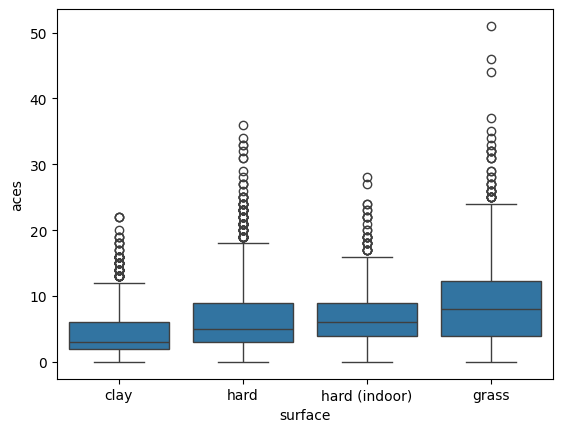

In [646]:
sns.boxplot(data=player_stats_df, y="aces", x="surface")

<Axes: xlabel='surface', ylabel='double_faults'>

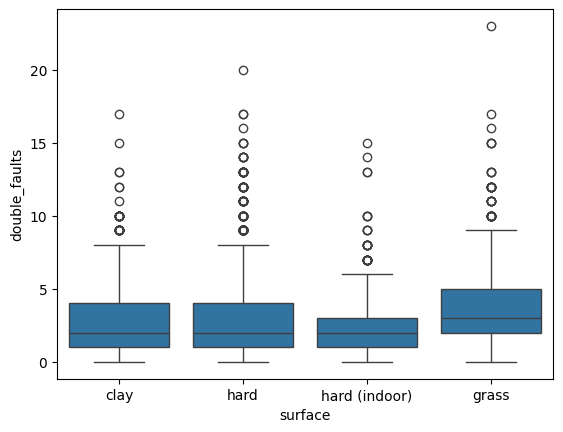

In [647]:
sns.boxplot(data=player_stats_df, y="double_faults", x="surface")

In [648]:
rankings_df = pd.read_csv("s3://matchedge-pipeline/data/clean/top_500_players.csv")

In [649]:
rankings_df = rankings_df.iloc[0:10,:]

In [650]:
rankings_df['rank'] = range(1, len(rankings_df) + 1)

In [651]:
player_stats_df = pd.merge(player_stats_df, rankings_df[["id", "rank"]], on="id", how="left").rename(columns={"rank": "live_ranking"})

In [652]:
player_stats_df

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,tournament_id,...,return_games_played,net_points_won,winners,unforced_errors,service_points_won,return_points_won,total_points_won,break_point_opportunities,net_points_played,live_ranking
0,2025-05-24,A. Rublev,F. Cobolli,0 days 01:28:37,Final,2 4,6 6,F. Cobolli,Completed,414,...,9.0,0.43,10.0,23.0,0.50,0.39,0.43,7.0,7.0,NaN
1,2025-05-23,F. Auger-Aliassime,A. Rublev,0 days 01:25:13,Semi-Finals,1 4,6 6,A. Rublev,Completed,414,...,9.0,0.00,15.0,24.0,0.57,0.27,0.42,1.0,2.0,NaN
2,2025-05-23,T. Etcheverry,F. Cobolli,0 days 02:47:54,Semi-Finals,6 5 4,2 7 6,F. Cobolli,Completed,414,...,15.0,0.75,20.0,34.0,0.62,0.40,0.51,7.0,16.0,NaN
3,2025-05-22,A. Rublev,L. Darderi,0 days 01:53:35,Quarter-Finals,6 3 6,1 6 3,A. Rublev,Completed,414,...,12.0,0.92,32.0,23.0,0.69,0.39,0.54,7.0,12.0,NaN
4,2025-05-22,A. Muller,F. Auger-Aliassime,0 days 02:58:31,Quarter-Finals,6(4) 7 3,7 6(6) 6,F. Auger-Aliassime,Completed,414,...,16.0,0.60,18.0,35.0,0.62,0.36,0.49,6.0,15.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8475,2025-07-19 00:00:00,N. Oberleitner,T. Monteiro,0 days 02:41:05,1st Round Qualifying,4 6 6(4),6 4 7,T. Monteiro,Completed,319,...,16.0,0.67,39.0,49.0,0.63,0.31,0.48,9.0,27.0,NaN
8476,2025-07-19 00:00:00,J. Kym,R. Albot,0 days 02:08:57,1st Round Qualifying,6 6(3) 3,2 7 6,R. Albot,Completed,319,...,15.0,0.17,27.0,45.0,0.65,0.42,0.52,10.0,6.0,NaN
8477,2025-07-19 00:00:00,H. Rocha,F. Bagnis,0 days 01:24:25,1st Round Qualifying,4 3,6 6,F. Bagnis,Completed,319,...,10.0,1.00,16.0,28.0,0.53,0.32,0.43,3.0,2.0,NaN
8478,2025-07-19 00:00:00,J. Rodionov,S. Kopp,0 days 01:20:52,1st Round Qualifying,6 7,3 6(3),J. Rodionov,Completed,319,...,10.0,0.67,26.0,25.0,0.66,0.33,0.52,3.0,9.0,NaN


<Axes: xlabel='live_ranking', ylabel='1st_serve_return_points_won'>

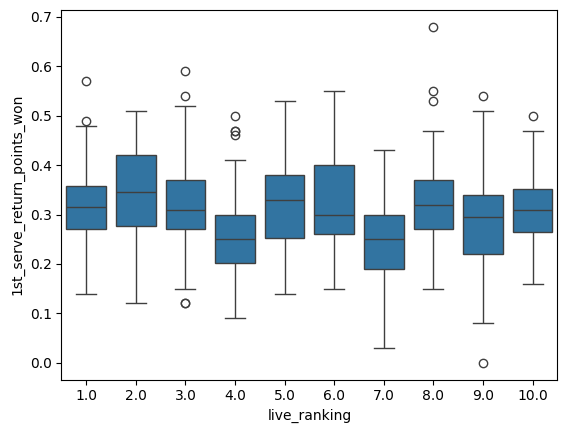

In [653]:
sns.boxplot(data=player_stats_df, y="1st_serve_return_points_won", x="live_ranking")

<Axes: xlabel='live_ranking', ylabel='2nd_serve_return_points_won'>

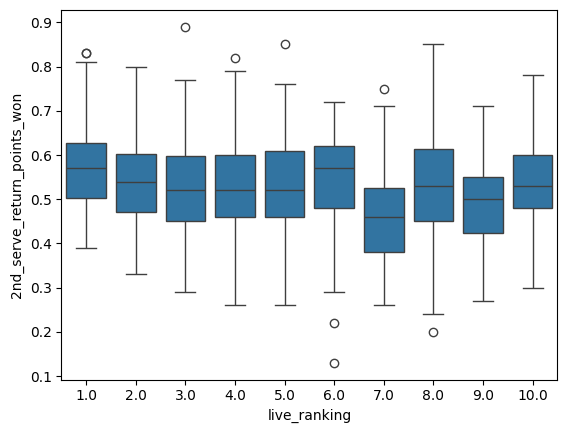

In [654]:
sns.boxplot(data=player_stats_df, y="2nd_serve_return_points_won", x="live_ranking")

In [655]:
avg_2nd_serve_return = player_stats_df.groupby(by=["live_ranking"])["2nd_serve_return_points_won"].mean().reset_index()

In [656]:
avg_2nd_serve_return

,live_ranking,2nd_serve_return_points_won
0,1.0,0.582581
1,2.0,0.544211
2,3.0,0.522561
3,4.0,0.531818
4,5.0,0.529516
5,6.0,0.539200
6,7.0,0.454571
7,8.0,0.530833
8,9.0,0.487419
9,10.0,0.539000


<Axes: xlabel='live_ranking', ylabel='2nd_serve_return_points_won'>

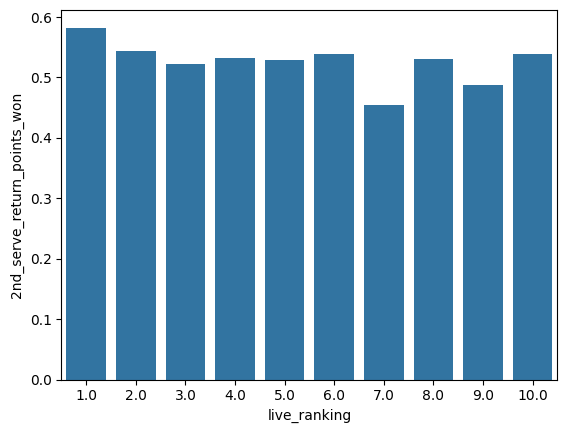

In [657]:
sns.barplot(data=avg_2nd_serve_return, y="2nd_serve_return_points_won", x="live_ranking")

In [658]:
avg_aces_top_10 = player_stats_df.groupby(by=["live_ranking"])["aces"].mean().reset_index()
avg_double_faults_top_10 = player_stats_df.groupby(by=["live_ranking"])["double_faults"].mean().reset_index()

<Axes: xlabel='live_ranking', ylabel='double_faults'>

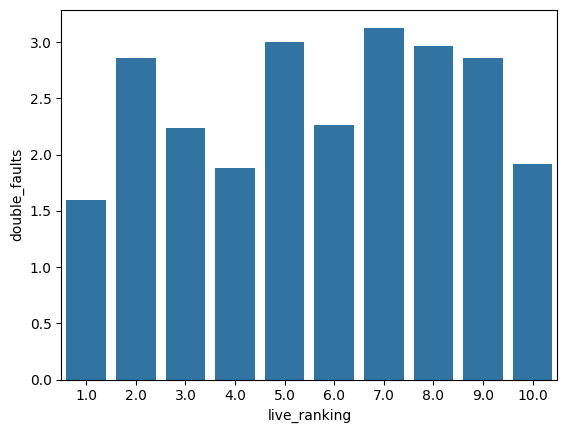

In [659]:
sns.barplot(data=avg_double_faults_top_10, y="double_faults", x="live_ranking")

<Axes: xlabel='live_ranking', ylabel='aces'>

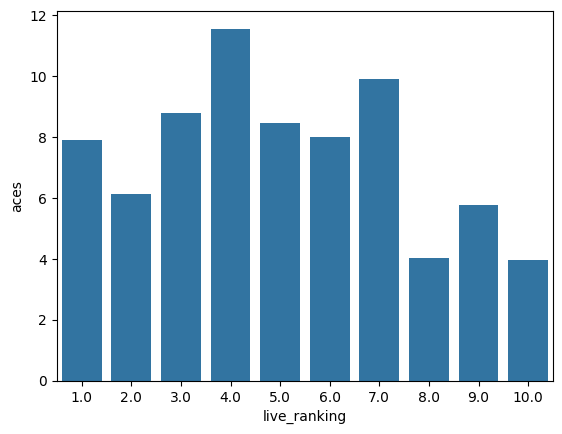

In [660]:
sns.barplot(data=avg_aces_top_10, y="aces", x="live_ranking")

In [661]:
rankings_df

,unnamed: 0,name,id,rank
0,0,J. Sinner,s0ag,1
1,1,C. Alcaraz,a0e2,2
2,2,A. Zverev,z355,3
3,3,T. Fritz,fb98,4
4,4,J. Draper,d0co,5
5,5,N. Djokovic,d643,6
6,6,B. Shelton,s0s1,7
7,7,A. de Minaur,dh58,8
8,8,H. Rune,r0dg,9
9,9,L. Musetti,m0ej,10


In [662]:
avg_aces = player_stats_df.groupby(by=["player"])["aces"].mean().reset_index().sort_values(by="aces", ascending=False).iloc[:10]
avg_double = player_stats_df.groupby(by=["player"])["double_faults"].mean().reset_index().sort_values(by="double_faults", ascending=False).iloc[:10]

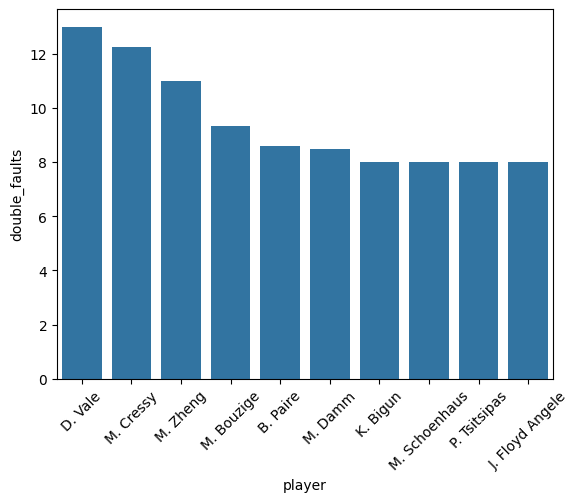

In [663]:
sns.barplot(data=avg_double, y="double_faults", x="player")
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

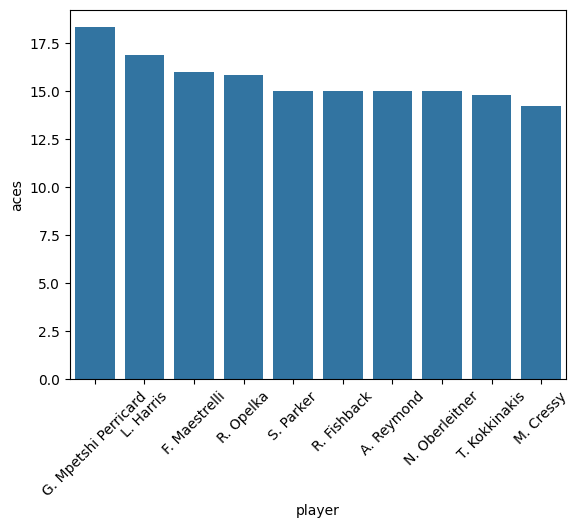

In [664]:
sns.barplot(data=avg_aces, y="aces", x="player")
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

Lets make sure they have a big enough sample size

In [665]:
match_counts = player_stats_df["player"].value_counts().reset_index()
match_counts.columns = ["player", "match_count"]

avg_stats = player_stats_df.groupby(by="player")[["aces", "double_faults"]].mean().reset_index()

avg_stats = avg_stats.merge(match_counts, on="player")

filtered_data = avg_stats[avg_stats["match_count"] >= 20]

avg_aces = filtered_data.sort_values(by="aces", ascending=False).head(10)
avg_double = filtered_data.sort_values(by="double_faults", ascending=False).head(10)

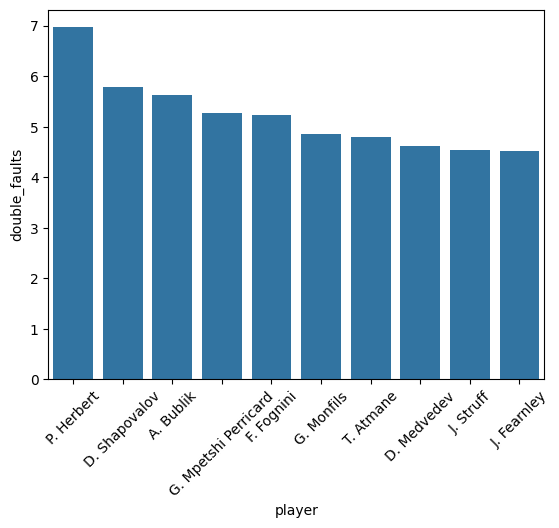

In [666]:
sns.barplot(data=avg_double, y="double_faults", x="player")
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

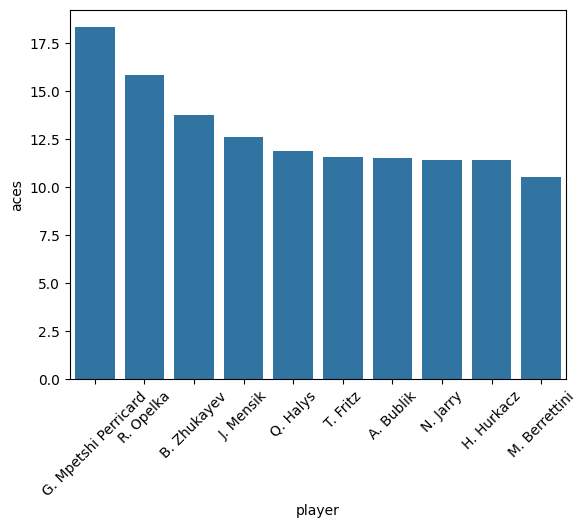

In [667]:
sns.barplot(data=avg_aces, y="aces", x="player")
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

In [668]:
player_stats_df.columns

Index(['match_date', 'player', 'opponent', 'duration', 'match_round',
       'player_scores', 'opponent_scores', 'winner', 'result', 'tournament_id',
       'id', 'opponent_id', 'set1', 'set2', 'set3', 'set4', 'set5',
       'opponent_set1', 'opponent_set2', 'opponent_set3', 'opponent_set4',
       'opponent_set5', 'best_of', 'winner_id', 'year', 'level', 'location',
       'surface', 'serve_rating', 'aces', 'double_faults', 'first_serve',
       '1st_serve_points_won', '2nd_serve_points_won', 'break_points_saved',
       'service_games_played', 'return_rating', '1st_serve_return_points_won',
       '2nd_serve_return_points_won', 'break_points_converted',
       'return_games_played', 'net_points_won', 'winners', 'unforced_errors',
       'service_points_won', 'return_points_won', 'total_points_won',
       'break_point_opportunities', 'net_points_played', 'live_ranking'],
      dtype='object')

Create an outcome column as 0 if player lost 1 if player won

In [669]:
player_stats_df["target"] = (player_stats_df["id"] == player_stats_df["winner_id"]).astype(int)

Do straight sets win/lost column.

In [670]:
player_stats_df["best_of"].value_counts()

best_of
3    6184
5    2296
Name: count, dtype: int64

In [671]:
def straight_sets_win(row):
    if row["target"] == 0:
        return 0 
    if row["best_of"] == 3 and pd.isna(row["set3"]):
        return 1
    if row["best_of"] == 5 and pd.isna(row["set4"]):
        return 1
    return 0

player_stats_df["straight_sets_win"] = player_stats_df.apply(straight_sets_win, axis=1)


In [672]:
player_stats_df["straight_sets_win"]

0       0
1       0
2       0
3       0
4       0
       ..
8475    0
8476    0
8477    0
8478    1
8479    0
Name: straight_sets_win, Length: 8480, dtype: int64

In [673]:
def straight_sets_loss(row):
    if row["target"] == 1:
        return 0  # Player won, can't be a straight-sets loss
    if row["best_of"] == 3 and pd.isna(row["opponent_set3"]):
        return 1
    if row["best_of"] == 5 and pd.isna(row["opponent_set4"]):
        return 1
    return 0

player_stats_df["straight_sets_loss"] = player_stats_df.apply(straight_sets_loss, axis=1)


In [674]:
player_stats_df

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,tournament_id,...,unforced_errors,service_points_won,return_points_won,total_points_won,break_point_opportunities,net_points_played,live_ranking,target,straight_sets_win,straight_sets_loss
0,2025-05-24,A. Rublev,F. Cobolli,0 days 01:28:37,Final,2 4,6 6,F. Cobolli,Completed,414,...,23.0,0.50,0.39,0.43,7.0,7.0,NaN,0,0,1
1,2025-05-23,F. Auger-Aliassime,A. Rublev,0 days 01:25:13,Semi-Finals,1 4,6 6,A. Rublev,Completed,414,...,24.0,0.57,0.27,0.42,1.0,2.0,NaN,0,0,1
2,2025-05-23,T. Etcheverry,F. Cobolli,0 days 02:47:54,Semi-Finals,6 5 4,2 7 6,F. Cobolli,Completed,414,...,34.0,0.62,0.40,0.51,7.0,16.0,NaN,0,0,0
3,2025-05-22,A. Rublev,L. Darderi,0 days 01:53:35,Quarter-Finals,6 3 6,1 6 3,A. Rublev,Completed,414,...,23.0,0.69,0.39,0.54,7.0,12.0,NaN,1,0,0
4,2025-05-22,A. Muller,F. Auger-Aliassime,0 days 02:58:31,Quarter-Finals,6(4) 7 3,7 6(6) 6,F. Auger-Aliassime,Completed,414,...,35.0,0.62,0.36,0.49,6.0,15.0,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8475,2025-07-19 00:00:00,N. Oberleitner,T. Monteiro,0 days 02:41:05,1st Round Qualifying,4 6 6(4),6 4 7,T. Monteiro,Completed,319,...,49.0,0.63,0.31,0.48,9.0,27.0,NaN,0,0,0
8476,2025-07-19 00:00:00,J. Kym,R. Albot,0 days 02:08:57,1st Round Qualifying,6 6(3) 3,2 7 6,R. Albot,Completed,319,...,45.0,0.65,0.42,0.52,10.0,6.0,NaN,0,0,0
8477,2025-07-19 00:00:00,H. Rocha,F. Bagnis,0 days 01:24:25,1st Round Qualifying,4 3,6 6,F. Bagnis,Completed,319,...,28.0,0.53,0.32,0.43,3.0,2.0,NaN,0,0,1
8478,2025-07-19 00:00:00,J. Rodionov,S. Kopp,0 days 01:20:52,1st Round Qualifying,6 7,3 6(3),J. Rodionov,Completed,319,...,25.0,0.66,0.33,0.52,3.0,9.0,NaN,1,1,0


#### Fix Some Issue With Retired Matches
When set 2 is missing this is definitely a RET

In [676]:
player_stats_df[['set1', 'set2', 'set3', 'set4', 'set5', 
                 'opponent_set1', 'opponent_set2', 'opponent_set3', 
                 'opponent_set4', 'opponent_set5']] = player_stats_df[['set1', 'set2', 'set3', 'set4', 'set5', 
                 'opponent_set1', 'opponent_set2', 'opponent_set3', 
                 'opponent_set4', 'opponent_set5']].astype('Int32')

In [677]:
mask = (player_stats_df["result"]=="Completed") & player_stats_df["set2"].isna()
player_stats_df.loc[mask, "result"] = "RET"

In best of 3 if second set didnt finish

In [678]:
mask = (player_stats_df["best_of"] == 3) & (player_stats_df["set2"] != 6) & (player_stats_df["set2"] != 7) &\
    (player_stats_df["opponent_set2"]!=6) & (player_stats_df["opponent_set2"]!=7) & (player_stats_df["result"] == "Completed")
player_stats_df.loc[mask, "result"] = "RET"

In best of 3 if third set didnt finish

In [679]:
mask = (player_stats_df["result"]=="Completed") & (player_stats_df["straight_sets_win"] == 0) &\
    (player_stats_df["straight_sets_loss"] == 0) & (player_stats_df["best_of"] == 3 ) &\
        (player_stats_df["set3"] != 6) & (player_stats_df["set3"] != 7) &\
            (player_stats_df["opponent_set3"]!=6) & (player_stats_df["opponent_set3"]!=7)

player_stats_df.loc[mask, "result"] = "RET"

In best of 5 if 3rd set is missing

In [680]:
mask = (player_stats_df["result"]=="Completed") & player_stats_df["set3"].isna() & (player_stats_df["best_of"] == 5) &\
    ~(player_stats_df["match_round"].str.contains('Qual'))
player_stats_df.loc[mask, "result"] = "RET"

Best of 5 win not win in straight but 3rd set not finished (and is not Next Gen ATP)

In [681]:
mask = (player_stats_df["result"]=="Completed") & (player_stats_df["straight_sets_win"] == 0) &\
    (player_stats_df["best_of"] == 5) & ~(player_stats_df["match_round"].str.contains('Qual')) &\
            (player_stats_df["set3"] != 6) & (player_stats_df["set3"] != 7) &\
            (player_stats_df["opponent_set3"]!=6) & (player_stats_df["opponent_set3"]!=7) &\
                (player_stats_df["tournament_id"] != 7696)
player_stats_df.loc[mask, "result"] = "RET"

In best of 5 sets and not in straight but set 4 not finished

In [682]:
mask = (player_stats_df["result"]=="Completed") & (player_stats_df["straight_sets_win"] == 0) &\
    (player_stats_df["best_of"] == 5) & ~(player_stats_df["match_round"].str.contains('Qual')) &\
            (player_stats_df["set4"] != 6) & (player_stats_df["set4"] != 7) &\
            (player_stats_df["opponent_set4"]!=6) & (player_stats_df["opponent_set4"]!=7) &\
                (player_stats_df["tournament_id"] != 7696)
player_stats_df.loc[mask, "result"] = "RET"

Where 5th set is not finished

In [683]:
mask = (player_stats_df["result"]=="Completed") & (player_stats_df["straight_sets_win"] == 0) &\
    (player_stats_df["best_of"] == 5) & ~(player_stats_df["match_round"].str.contains('Qual')) &\
            (player_stats_df["set5"] != 6) & (player_stats_df["set5"] != 7) &\
            (player_stats_df["opponent_set5"]!=6) & (player_stats_df["opponent_set5"]!=7) &\
                (player_stats_df["tournament_id"] != 7696)
player_stats_df.loc[mask, "result"] = "RET"

In [684]:
player_stats_df["result"].value_counts()

result
Completed    8266
RET           214
Name: count, dtype: int64

Change Qualifying round using str.contains('Qual) to best of 3

In [685]:
mask = (player_stats_df["best_of"] == 5) & (player_stats_df["match_round"].str.contains('Qual'))
player_stats_df.loc[mask, "best_of"] = 3

In [686]:
player_stats_df["best_of"].value_counts()

best_of
3    7218
5    1262
Name: count, dtype: int64

Create number of sets won/lost.

In [687]:
# List of player and opponent set columns in order
player_sets = ['set1', 'set2', 'set3', 'set4', 'set5']
opponent_sets = ['opponent_set1', 'opponent_set2', 'opponent_set3', 'opponent_set4', 'opponent_set5']

# Compute per-set win booleans for player
set_wins = pd.DataFrame({
    p: ((player_stats_df[p] == 6) & (player_stats_df[o] <= 4)) |  # normal win
       ((player_stats_df[p] == 7) & (player_stats_df[o] >= 5))    # tiebreak win
    for p, o in zip(player_sets, opponent_sets)
})

# Count wins per row for player
player_stats_df["sets_won"] = set_wins.sum(axis=1)

# Compute per-set win booleans for opponent
set_loses = pd.DataFrame({
    o: ((player_stats_df[o] == 6) & (player_stats_df[p] <= 4)) |  # normal win
       ((player_stats_df[o] == 7) & (player_stats_df[p] >= 5))    # tiebreak win
    for p, o in zip(player_sets, opponent_sets)
})

# Count wins for opponent per row
player_stats_df["sets_lost"] = set_loses.sum(axis=1)

In [688]:
player_stats_df

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,tournament_id,...,total_points_won,break_point_opportunities,net_points_played,live_ranking,target,straight_sets_win,straight_sets_loss,no_sets_won,sets_won,sets_lost
0,2025-05-24,A. Rublev,F. Cobolli,0 days 01:28:37,Final,2 4,6 6,F. Cobolli,Completed,414,...,0.43,7.0,7.0,NaN,0,0,1,NaN,0,2
1,2025-05-23,F. Auger-Aliassime,A. Rublev,0 days 01:25:13,Semi-Finals,1 4,6 6,A. Rublev,Completed,414,...,0.42,1.0,2.0,NaN,0,0,1,NaN,0,2
2,2025-05-23,T. Etcheverry,F. Cobolli,0 days 02:47:54,Semi-Finals,6 5 4,2 7 6,F. Cobolli,Completed,414,...,0.51,7.0,16.0,NaN,0,0,0,NaN,1,2
3,2025-05-22,A. Rublev,L. Darderi,0 days 01:53:35,Quarter-Finals,6 3 6,1 6 3,A. Rublev,Completed,414,...,0.54,7.0,12.0,NaN,1,0,0,NaN,2,1
4,2025-05-22,A. Muller,F. Auger-Aliassime,0 days 02:58:31,Quarter-Finals,6(4) 7 3,7 6(6) 6,F. Auger-Aliassime,Completed,414,...,0.49,6.0,15.0,NaN,0,0,0,NaN,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8475,2025-07-19 00:00:00,N. Oberleitner,T. Monteiro,0 days 02:41:05,1st Round Qualifying,4 6 6(4),6 4 7,T. Monteiro,Completed,319,...,0.48,9.0,27.0,NaN,0,0,0,NaN,1,2
8476,2025-07-19 00:00:00,J. Kym,R. Albot,0 days 02:08:57,1st Round Qualifying,6 6(3) 3,2 7 6,R. Albot,Completed,319,...,0.52,10.0,6.0,NaN,0,0,0,NaN,1,2
8477,2025-07-19 00:00:00,H. Rocha,F. Bagnis,0 days 01:24:25,1st Round Qualifying,4 3,6 6,F. Bagnis,Completed,319,...,0.43,3.0,2.0,NaN,0,0,1,NaN,0,2
8478,2025-07-19 00:00:00,J. Rodionov,S. Kopp,0 days 01:20:52,1st Round Qualifying,6 7,3 6(3),J. Rodionov,Completed,319,...,0.52,3.0,9.0,NaN,1,1,0,2.0,2,0


In [695]:
df_matches[df_matches["winner_id"]=="d643"]

,match_date,player_1,player_2,duration,match_round,player_1_scores,player_2_scores,winner,result,match_id,...,p2_service_points_won,p2_return_points_won,p2_total_points_won,p2_max_speed,p2_1st_serve_average_speed,p2_2nd_serve_average_speed,p2_break_point_opportunities,p1_break_point_opportunities,p1_net_points_played,p2_net_points_played
87,2025-01-02,N. Djokovic,G. Monfils,0 days 01:12:49,Round of 16,6 6,3 3,N. Djokovic,Completed,ms008,...,0.56,0.27,0.41,NaN,NaN,NaN,1.0,3.0,10.0,2.0
95,2024-12-31,N. Djokovic,R. Hijikata,0 days 01:14:39,Round of 32,6 6,3 3,N. Djokovic,Completed,ms016,...,0.56,0.21,0.40,NaN,NaN,NaN,0.0,5.0,10.0,5.0
246,2025-01-21,N. Djokovic,C. Alcaraz,NaN,Quarter-Finals,4 6 6 6,6 4 3 4,N. Djokovic,Completed,ms006,...,0.58,0.39,0.48,NaN,NaN,NaN,11.0,13.0,0.0,0.0
249,2025-01-19,N. Djokovic,J. Lehecka,NaN,Round of 16,6 6 7,3 4 6(4),N. Djokovic,Completed,ms012,...,0.60,0.26,0.45,NaN,NaN,NaN,1.0,8.0,0.0,0.0
261,2025-01-17,N. Djokovic,T. Machac,NaN,Round of 32,6 6 6,1 4 4,N. Djokovic,Completed,ms024,...,0.54,0.29,0.42,NaN,NaN,NaN,3.0,15.0,0.0,0.0
286,2025-01-15,N. Djokovic,J. Faria,NaN,Round of 64,6 6(4) 6 6,1 7 3 2,N. Djokovic,Completed,ms048,...,0.53,0.32,0.42,NaN,NaN,NaN,7.0,12.0,0.0,0.0
326,2025-01-13,N. Djokovic,N. Basavareddy,NaN,Round of 128,4 6 6 6,6 3 4 2,N. Djokovic,Completed,ms096,...,0.60,0.27,0.45,NaN,NaN,NaN,3.0,11.0,0.0,0.0
1041,2025-03-28,N. Djokovic,G. Dimitrov,0 days 01:10:10,Semi-Finals,6 6,2 3,N. Djokovic,Completed,ms003,...,0.51,0.27,0.39,NaN,NaN,NaN,2.0,6.0,2.0,7.0
1043,2025-03-27,S. Korda,N. Djokovic,0 days 01:22:17,Quarter-Finals,3 6(4),6 7,N. Djokovic,Completed,ms006,...,0.80,0.30,0.56,NaN,NaN,NaN,2.0,1.0,5.0,5.0
1048,2025-03-25,L. Musetti,N. Djokovic,0 days 01:23:03,Round of 16,2 2,6 6,N. Djokovic,Completed,ms013,...,0.70,0.54,0.61,NaN,NaN,NaN,12.0,1.0,6.0,11.0


---

In [696]:
player_stats_df

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,tournament_id,...,total_points_won,break_point_opportunities,net_points_played,live_ranking,target,straight_sets_win,straight_sets_loss,no_sets_won,sets_won,sets_lost
0,2025-05-24,A. Rublev,F. Cobolli,0 days 01:28:37,Final,2 4,6 6,F. Cobolli,Completed,414,...,0.43,7.0,7.0,NaN,0,0,1,NaN,0,2
1,2025-05-23,F. Auger-Aliassime,A. Rublev,0 days 01:25:13,Semi-Finals,1 4,6 6,A. Rublev,Completed,414,...,0.42,1.0,2.0,NaN,0,0,1,NaN,0,2
2,2025-05-23,T. Etcheverry,F. Cobolli,0 days 02:47:54,Semi-Finals,6 5 4,2 7 6,F. Cobolli,Completed,414,...,0.51,7.0,16.0,NaN,0,0,0,NaN,1,2
3,2025-05-22,A. Rublev,L. Darderi,0 days 01:53:35,Quarter-Finals,6 3 6,1 6 3,A. Rublev,Completed,414,...,0.54,7.0,12.0,NaN,1,0,0,NaN,2,1
4,2025-05-22,A. Muller,F. Auger-Aliassime,0 days 02:58:31,Quarter-Finals,6(4) 7 3,7 6(6) 6,F. Auger-Aliassime,Completed,414,...,0.49,6.0,15.0,NaN,0,0,0,NaN,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8475,2025-07-19 00:00:00,N. Oberleitner,T. Monteiro,0 days 02:41:05,1st Round Qualifying,4 6 6(4),6 4 7,T. Monteiro,Completed,319,...,0.48,9.0,27.0,NaN,0,0,0,NaN,1,2
8476,2025-07-19 00:00:00,J. Kym,R. Albot,0 days 02:08:57,1st Round Qualifying,6 6(3) 3,2 7 6,R. Albot,Completed,319,...,0.52,10.0,6.0,NaN,0,0,0,NaN,1,2
8477,2025-07-19 00:00:00,H. Rocha,F. Bagnis,0 days 01:24:25,1st Round Qualifying,4 3,6 6,F. Bagnis,Completed,319,...,0.43,3.0,2.0,NaN,0,0,1,NaN,0,2
8478,2025-07-19 00:00:00,J. Rodionov,S. Kopp,0 days 01:20:52,1st Round Qualifying,6 7,3 6(3),J. Rodionov,Completed,319,...,0.52,3.0,9.0,NaN,1,1,0,2.0,2,0


Winner id thats neither player_id or opponent_id

In [700]:
mask = (player_stats_df["winner_id"] != player_stats_df["id"]) & \
       (player_stats_df["winner_id"] != player_stats_df["opponent_id"])

mismatches = player_stats_df[mask]

player_stats_df["winner_not_in_match"] = (
    (player_stats_df["winner_id"] != player_stats_df["id"]) &
    (player_stats_df["winner_id"] != player_stats_df["opponent_id"])
)
mismatch_count = (
    ((player_stats_df["winner_id"] != player_stats_df["id"]) &
     (player_stats_df["winner_id"] != player_stats_df["opponent_id"]))
    .sum()
)

print(mismatch_count)


174


In [701]:
player_stats_df[player_stats_df["winner_not_in_match"]==True]

,match_date,player,opponent,duration,match_round,player_scores,opponent_scores,winner,result,tournament_id,...,break_point_opportunities,net_points_played,live_ranking,target,straight_sets_win,straight_sets_loss,no_sets_won,sets_won,sets_lost,winner_not_in_match
77,2024-07-21,F. Krajinovic,C. Tseng,0 days 02:01:00,1st Round Qualifying,6 2 6,4 6 1,F. Krajinovic,Completed,414,...,8.0,22.0,NaN,0,0,0,NaN,2,1,True
79,2024-07-21,M. Moeller,N. Hardt,0 days 01:38:00,1st Round Qualifying,2 4,6 6,N. Hardt,Completed,414,...,4.0,29.0,NaN,0,0,1,NaN,0,2,True
194,2025-01-05,Q. Halys,J. Bradshaw,0 days 00:19:05,1st Round Qualifying,2,2,J. Bradshaw,RET,8998,...,0.0,3.0,NaN,0,0,1,NaN,0,0,True
389,2025-01-08,A. Holmgren,J. Kovalik,NaN,2nd Round Qualifying,7 3 5,6(3) 6 7,J. Kovalik,Completed,580,...,10.0,0.0,NaN,0,0,1,NaN,1,2,True
420,2025-01-07,B. Tomic,J. Kovalik,NaN,1st Round Qualifying,3 1,6 6,J. Kovalik,Completed,580,...,0.0,0.0,NaN,0,0,1,NaN,0,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8161,2025-06-26 00:00:00,L. Riedi,H. Stewart,NaN,3rd Round Qualifying,6 4 6 6,3 6 3 4,L. Riedi,Completed,540,...,12.0,0.0,NaN,0,0,0,NaN,3,1,True
8206,2025-06-23 00:00:00,V. Durasovic,O. Bonding,NaN,1st Round Qualifying,5 6 4,7 2 6,O. Bonding,Completed,540,...,7.0,0.0,NaN,0,0,1,NaN,1,2,True
8213,2025-06-23 00:00:00,A. Escoffier,J. Kovalik,NaN,1st Round Qualifying,4 7 6(7),6 6(5) 7,J. Kovalik,Completed,540,...,13.0,0.0,NaN,0,0,1,NaN,1,2,True
8241,2025-07-15 00:00:00,L. Carlos Alvarez,J. McCabe,0 days 01:13:16,Round of 32,6 6,1 2,L. Carlos Alvarez,Completed,7480,...,7.0,3.0,NaN,0,0,1,NaN,2,0,True


In [ ]:
mismatch_count = (
    ((player_stats_df["winner_id"] != player_stats_df["id"]) &
     (player_stats_df["winner_id"] != player_stats_df["opponent_id"]))
    .sum()
)

mismatch_pct = mismatch_count / len(player_stats_df) * 100


In [721]:
print(mismatch_pct)

2.05188679245283


2% are wrong. I think thats ok for now.

In [727]:
player_stats_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8480 entries, 0 to 8479
Data columns (total 56 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   match_date                   8480 non-null   object 
 1   player                       8480 non-null   object 
 2   opponent                     8480 non-null   object 
 3   duration                     7150 non-null   object 
 4   match_round                  8480 non-null   object 
 5   player_scores                8480 non-null   object 
 6   opponent_scores              8480 non-null   object 
 7   winner                       8480 non-null   object 
 8   result                       8480 non-null   object 
 9   tournament_id                8480 non-null   int64  
 10  id                           8393 non-null   object 
 11  opponent_id                  8393 non-null   object 
 12  set1                         8480 non-null   Int32  
 13  set2              

Delete some redundant columns

In [729]:
player_stats_df.drop(columns=["player_scores", "opponent_scores"], inplace=True)

In [730]:
player_stats_df

,match_date,player,opponent,duration,match_round,winner,result,tournament_id,id,opponent_id,...,total_points_won,break_point_opportunities,net_points_played,live_ranking,target,straight_sets_win,straight_sets_loss,sets_won,sets_lost,winner_not_in_match
0,2025-05-24,A. Rublev,F. Cobolli,0 days 01:28:37,Final,F. Cobolli,Completed,414,re44,c0e9,...,0.43,7.0,7.0,NaN,0,0,1,0,2,False
1,2025-05-23,F. Auger-Aliassime,A. Rublev,0 days 01:25:13,Semi-Finals,A. Rublev,Completed,414,ag37,re44,...,0.42,1.0,2.0,NaN,0,0,1,0,2,False
2,2025-05-23,T. Etcheverry,F. Cobolli,0 days 02:47:54,Semi-Finals,F. Cobolli,Completed,414,ea24,c0e9,...,0.51,7.0,16.0,NaN,0,0,0,1,2,False
3,2025-05-22,A. Rublev,L. Darderi,0 days 01:53:35,Quarter-Finals,A. Rublev,Completed,414,re44,d0fj,...,0.54,7.0,12.0,NaN,1,0,0,2,1,False
4,2025-05-22,A. Muller,F. Auger-Aliassime,0 days 02:58:31,Quarter-Finals,F. Auger-Aliassime,Completed,414,mp20,ag37,...,0.49,6.0,15.0,NaN,0,0,0,1,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8475,2025-07-19 00:00:00,N. Oberleitner,T. Monteiro,0 days 02:41:05,1st Round Qualifying,T. Monteiro,Completed,319,o0ad,mj08,...,0.48,9.0,27.0,NaN,0,0,0,1,2,False
8476,2025-07-19 00:00:00,J. Kym,R. Albot,0 days 02:08:57,1st Round Qualifying,R. Albot,Completed,319,k0ep,a829,...,0.52,10.0,6.0,NaN,0,0,0,1,2,False
8477,2025-07-19 00:00:00,H. Rocha,F. Bagnis,0 days 01:24:25,1st Round Qualifying,F. Bagnis,Completed,319,r0go,bf23,...,0.43,3.0,2.0,NaN,0,0,1,0,2,False
8478,2025-07-19 00:00:00,J. Rodionov,S. Kopp,0 days 01:20:52,1st Round Qualifying,J. Rodionov,Completed,319,r09x,k0cj,...,0.52,3.0,9.0,NaN,1,1,0,2,0,False


#### Save DataFrame

In [732]:
player_stats_df.to_csv("/Users/samueleferrucci/Documents/Coding/Projects/Tennis ML/data/ML-Dashboard/player_stats.csv", sep=",", columns=player_stats_df.columns, index=False)